# Convert jupyter to python

In [14]:
!jupyter nbconvert --to script fetching_monthly_intraday_data.ipynb

[NbConvertApp] Converting notebook fetching_monthly_intraday_data.ipynb to script
[NbConvertApp] Writing 13008 bytes to fetching_monthly_intraday_data.py


# Code

#### All Functions

In [1]:
### Step 1: Import Required Libraries
import datetime
from datetime import date, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import os
import matplotlib.dates as mdates
from copy import deepcopy

def convert_to_bps_ticks(df,bps_per_instrument=8/0.99,ticks_per_instrument=32/0.99):
    '''
    0.99 (ZN price pts) change = 32 ticks or 8bps; This is what I understand for ZN.
    So 1 bp is 0,12375 ZN price points.
    So 1ZN price pts change= 32/0.99 ticks per zn
    So 1ZN price pts change= 8/0.99  bps per zn
    '''
    b=bps_per_instrument
    t=ticks_per_instrument
    df_b=df*bps_per_instrument
    df_t=df*ticks_per_instrument
    return pd.concat((df_b,df_t),axis=1)
    
### Step 2: Fetching and Preprocessing Data
def get_market_data(symbols, start_date, end_date, interval="1d", period='Not Defined',return_change=False): #Adj Close data for a lot many days
    closing_prices = yf.download(
        symbols, start=start_date, end=end_date, interval=interval
    )["Adj Close"] #or close same thing.
    #---Above code gives pandas dataframe in general. ["Adj Close"] gives adjusted close price after dividend.
    
    closing_prices.columns = (
        closing_prices.columns.str.replace("=F", "")
        .str.replace("DX-Y.NYB", "DXY")
        .str.replace("^", "")
    )
    if return_change:
        return closing_prices.pct_change().dropna()
    return closing_prices.dropna()


def get_intraday_data(symbol, interval="5m", period="60d", start_date=None):  # Same as get_market_data
    if start_date:
        end_date = start_date - datetime.timedelta(days=int(period.replace("d", "")))
        df = yf.download(symbol, start=end_date, end=start_date, interval=interval)
    else:
        df = yf.Ticker(symbol).history(period=period, interval=interval)

    # Modify column names to remove '=F' or other extensions
    simplified_name = (
        symbol.replace("=F", "").replace("DX-Y.NYB", "DXY").str.replace("^", "")
    )
    df.rename(columns={"Close": simplified_name}, inplace=True)
    return df[[simplified_name]]


def split_periods(data):
    periods = {
        "us_open": data.between_time("07:00:00", "11:00:00").sort_index(),
        "us_mid": data.between_time("11:00:01", "15:00:00").sort_index(),
        "us_close": data.between_time("15:00:01", "17:00:00").sort_index(),
        "us_apac": data.between_time("17:00:01", "02:00:00").sort_index(),
        "us_emea": data.between_time("02:00:01", "07:00:00").sort_index(),
    }
    return periods


def get_company_name(ticker):
    try:
        company = yf.Ticker(ticker)
        return company.info["longName"]
    except:
        try:
            company = yf.Ticker(ticker)
            return company.info["shortName"]
        except:
            return ticker  # Return the original ticker if unable to fetch the name

#### Tickers and corresponding symbols

In [2]:
dict_tickers = {
    "ZN=F": "10-Year T-Note Futures",
    "DX-Y.NYB": "US Dollar Index",
    "CL=F": "Crude Oil futures",
    "GC=F": "Gold futures",
    "NQ=F": "Nasdaq 100 futures",
    "^DJI": "Dow Jones Industrial Average",
    "^GSPC": "S&P 500"}
    # "FGBL=F":"German 10-Year Bund", #Not sure
	# "FOAT=F":"French 10-Year OAT", #Not sure
	# "G=F":"UK 10-Year Gilt"} #Not sure

dict_symbols = {
     "ZN=F":["ZN","10-Year T-Note Futures"],
    "DX-Y.NYB":["DXY","US Dollar Index"],
     "CL=F":["CL","Crude Oil futures"],
     "GC=F":["GC","Gold futures"],
     "NQ=F":["NQ","Nasdaq 100 futures"],
    "^DJI":["DJI","Dow Jones Industrial Average"],
     "^GSPC":["GSPC","S&P 500"]}
    # "FGBL":"German 10-Year Bund",
    # "FOAT":"French 10-year OAT",
    # "G": "UK 10-Year Gilt"
print(dict_symbols)

{'ZN=F': ['ZN', '10-Year T-Note Futures'], 'DX-Y.NYB': ['DXY', 'US Dollar Index'], 'CL=F': ['CL', 'Crude Oil futures'], 'GC=F': ['GC', 'Gold futures'], 'NQ=F': ['NQ', 'Nasdaq 100 futures'], '^DJI': ['DJI', 'Dow Jones Industrial Average'], '^GSPC': ['GSPC', 'S&P 500']}


#### Getting intervals for last 1 month intra-day data i.e interval=1m

In [3]:
# Get today's date
today = (datetime.datetime.now())
latest_intraday=(today-timedelta(days=1)).strftime("%Y-%m-%d")#doing this to get complete data of previous day
# Calculate the date one month ago
one_month_ago = today - timedelta(days=29)
last_intraday = one_month_ago.strftime("%Y-%m-%d")
start_intraday=latest_intraday
end_intraday=last_intraday
print(f'Fetching Intraday data (1m interval) from {start_intraday} to {last_intraday}')
# Make List of all possible Start-End dates between today and today-30
alldates=[]
for i in range(29,0,-7):
    alldates.append((today-timedelta(days=i)).strftime("%Y-%m-%d"))
grouped_start_last_dates=[[a,b] for a,b in zip(alldates,alldates[1:])]
dates=grouped_start_last_dates
print(dates)

Fetching Intraday data (1m interval) from 2024-11-12 to 2024-10-15
[['2024-10-15', '2024-10-22'], ['2024-10-22', '2024-10-29'], ['2024-10-29', '2024-11-05'], ['2024-11-05', '2024-11-12']]


#### Get 1month intraday data (1m interval) for all tickers

In [4]:
###Step5: Intraday returns (High - Low)
def combine_all_data(list_of_first_last,list_of_symbols): # Append the data for all the Start-End dates
    datalist=[]
    for data in list_of_first_last:
        start=last_intraday=data[0]
        end=latest_intraday=data[1]
        interval='1m'
        data = yf.download(list_of_symbols, start=start, end=end, interval=interval) #Returns a dataframe
        datalist.append(data)
    return(pd.concat(datalist))

print("Today's date:", start_intraday)
print("Date one month ago:", end_intraday)

# Save distribution of daily returns
# Create output directory if it doesn't exist
output_dir = "output_monthly_intraday"
os.makedirs(output_dir, exist_ok=True)
name = f"{end_intraday}_to_{start_intraday}"


alltickers=list(dict_symbols.keys())
allsymbols=[i[0] for i in list(dict_symbols.values())]

print('Symbols',allsymbols)
print('Tickers',alltickers)
# Fetch Data
data = combine_all_data(grouped_start_last_dates,list_of_symbols=alltickers)
tickers_as_columns=data.stack(level=0,future_stack=False)
for col in tickers_as_columns.columns:
    col_data=tickers_as_columns[col].unstack()
    dict_symbols[col].append(col_data)

Today's date: 2024-11-12
Date one month ago: 2024-10-15
Symbols ['ZN', 'DXY', 'CL', 'GC', 'NQ', 'DJI', 'GSPC']
Tickers ['ZN=F', 'DX-Y.NYB', 'CL=F', 'GC=F', 'NQ=F', '^DJI', '^GSPC']


[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
/var/folders/qc/knz8bs196t30_fkh2jr17kh80000gn/T/ipykernel_22782/529341173.py:29: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tickers_as_columns=data.stack(level=0,future_stack=False)


#### Get 1month Intraday data for ZN in bps and ticks

In [5]:
zn_intraday_data_pts=deepcopy(dict_symbols['ZN=F'][2])
zn_returns=zn_intraday_data_pts['Close'] # or Adj Close. Both are same in options and futures.
zn_returns_change=abs(zn_returns.diff(-1))#next-initial row absolute difference
zn_returns_change=zn_returns_change.dropna() #removing the last null row.
zn_returns_change_bps_ticks=convert_to_bps_ticks(zn_returns_change,
                                           bps_per_instrument=8/0.99,
                                           ticks_per_instrument=32/0.99)

df_zn_returns_change_bps_ticks=pd.DataFrame(zn_returns_change_bps_ticks)
df_zn_returns_change_bps_ticks.columns=pd.Index(['bps','ticks'],name='ZN Returns')
print(df_zn_returns_change_bps_ticks)

# Save distribution of ZN returns
# Create output directory if it doesn't exist
zn_output_dir = "output_monthly_intraday_bps_ticks_ZN"
os.makedirs(zn_output_dir, exist_ok=True)
zn_name = f"{end_intraday}_to_{start_intraday}"
zn_output_file_0= os.path.join(
            zn_output_dir, "ZN_Intraday_returns_data_"+f"{zn_name}.csv"
        )
df_zn_returns_change_bps_ticks.to_csv(zn_output_file_0)

ZN Returns                      bps     ticks
Datetime                                     
2024-10-15 04:00:00+00:00  0.000000  0.000000
2024-10-15 04:01:00+00:00  0.000000  0.000000
2024-10-15 04:02:00+00:00  0.000000  0.000000
2024-10-15 04:03:00+00:00  0.000000  0.000000
2024-10-15 04:09:00+00:00  0.126263  0.505051
...                             ...       ...
2024-11-12 04:53:00+00:00  0.000000  0.000000
2024-11-12 04:54:00+00:00  0.126263  0.505051
2024-11-12 04:55:00+00:00  0.000000  0.000000
2024-11-12 04:56:00+00:00  0.000000  0.000000
2024-11-12 04:57:00+00:00  0.126263  0.505051

[24664 rows x 2 columns]


#### Data Stats for all tickers

In [20]:
#1. All tickers intraday data in pts
print(f"\nLast one month - Intraday data Summary {start_intraday} to {end_intraday} for all tickers:")
output_file_all = os.path.join(
            output_dir, "All_tickers_Intraday_monthly_data_summary_"+f"{name}.csv"
        )
data.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_csv(output_file_all)
data.describe()


Last one month - Intraday data Summary 2024-11-09 to 2024-10-12 for all tickers:


Price      Adj Close                                                          \
Ticker          CL=F      DX-Y.NYB          GC=F          NQ=F          ZN=F   
count   24746.000000  26822.000000  27266.000000  27120.000000  25708.000000   
mean       70.556091    103.994268   2731.145514  20496.199226    111.064647   
std         1.595279      0.509137     37.073808    271.566702      0.858572   
min        66.750000    102.915001   2653.300049  20012.750000    109.234375   
25%        69.820000    103.627998   2697.300049  20347.750000    110.421875   
50%        70.699997    104.025002   2743.399902  20462.500000    110.984375   
75%        71.529999    104.307999   2753.800049  20614.250000    111.906250   
max        74.830002    105.431000   2801.399902  21262.750000    112.687500   

Price                                     Close                              \
Ticker          ^DJI        ^GSPC          CL=F      DX-Y.NYB          GC=F   
count    7759.000000  7759.000000  24746.000000  26822.000000  27266.000000   
mean    42740.665123  5835.694628     70.556091    103.994268   2731.145514   
std       602.932979    67.323053      1.595279      0.509137     37.073808   
min     41652.101562  5696.910156     66.750000    102.915001   2653.300049   
25%     42284.464844  5806.050049     69.820000    103.627998   2697.300049   
50%     42736.910156  5836.810059     70.699997    104.025002   2743.399902   
75%     43133.511719  5857.604980     71.529999    104.307999   2753.800049   
max     44155.589844  6012.310059     74.830002    105.431000   2801.399902   

Price   ...          Open                                   Volume           \
Ticker  ...          ZN=F          ^DJI        ^GSPC          CL=F DX-Y.NYB   
count   ...  25708.000000   7759.000000  7759.000000  24746.000000  26822.0   
mean    ...    111.064653  42740.608703  5835.691114    199.857068      0.0   
std     ...      0.858551    602.754991    67.302194    446.301517      0.0   
min     ...    109.234375  41650.351562  5696.830078      0.000000      0.0   
25%     ...    110.421875  42284.525391  5806.049805     22.000000      0.0   
50%     ...    110.984375  42737.949219  5836.779785     75.000000      0.0   
75%     ...    111.906250  43132.914062  5857.675049    220.000000      0.0   
max     ...    112.687500  44155.460938  6012.270020  18662.000000      0.0   

Price                                                                          
Ticker          GC=F          NQ=F           ZN=F          ^DJI         ^GSPC  
count   27266.000000  27120.000000   25708.000000  7.759000e+03  7.759000e+03  
mean      138.305435    361.566409    1653.808698  6.817912e+05  5.189633e+06  
std       344.781731    594.233769    3559.921634  6.726168e+05  4.752531e+06  
min         0.000000      0.000000       0.000000  0.000000e+00  0.000000e+00  
25%        33.000000     47.000000      71.000000  3.854760e+05  3.189655e+06  
50%        72.000000    110.000000     555.000000  5.209830e+05  4.090000e+06  
75%       156.000000    445.000000    2120.000000  7.460515e+05  5.631500e+06  
max     33040.000000  12314.000000  223117.000000  1.278991e+07  9.113100e+07  

[8 rows x 42 columns]

In [21]:
#2. ZN returns data in bps and ticks
print(f"\nLast one month - Intraday returns data Summary {start_intraday} to {end_intraday} for ZN (bps and ticks):")
zn_output_file= os.path.join(
            zn_output_dir, "ZN_Intraday_returns_data_summary_"+f"{zn_name}.csv"
        )
df_zn_returns_change_bps_ticks.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_csv(zn_output_file)
df_zn_returns_change_bps_ticks.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


Last one month - Intraday returns data Summary 2024-11-09 to 2024-10-12 for ZN (bps and ticks):


ZN Returns,bps,ticks
count,24561.000000,24561.000000
mean,0.075909,0.303634
std,0.095515,0.382059
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.126263,0.505051
75%,0.126263,0.505051
90%,0.126263,0.505051
95%,0.252525,1.010101
99%,0.378788,1.515152


#### Plotting intra day Returns data for all tickers with X-Axis having all dates from start to end

In [22]:
for key_of_col in list(dict_symbols.keys()):
    sy=(dict_symbols[key_of_col][0])
    print(sy)

ZN
DXY
CL
GC
NQ
DJI
GSPC



Last one month - Intraday returns data Summary 2024-11-09 to 2024-10-12 for ZN (bps and ticks):
Price                       Adj Close       Close        High         Low  \
Datetime                                                                    
2024-10-13 21:12:00+00:00         NaN         NaN         NaN         NaN   
2024-10-13 22:00:00+00:00  112.015625  112.015625  112.093750  112.000000   
2024-10-13 22:01:00+00:00  112.046875  112.046875  112.046875  112.015625   
2024-10-13 22:02:00+00:00  112.031250  112.031250  112.046875  112.031250   
2024-10-13 22:03:00+00:00  112.031250  112.031250  112.046875  112.031250   
...                               ...         ...         ...         ...   
2024-11-08 21:55:00+00:00  110.250000  110.250000  110.265625  110.250000   
2024-11-08 21:56:00+00:00  110.265625  110.265625  110.265625  110.250000   
2024-11-08 21:57:00+00:00  110.250000  110.250000  110.265625  110.250000   
2024-11-08 21:58:00+00:00  110.265625  110.265625  110.2

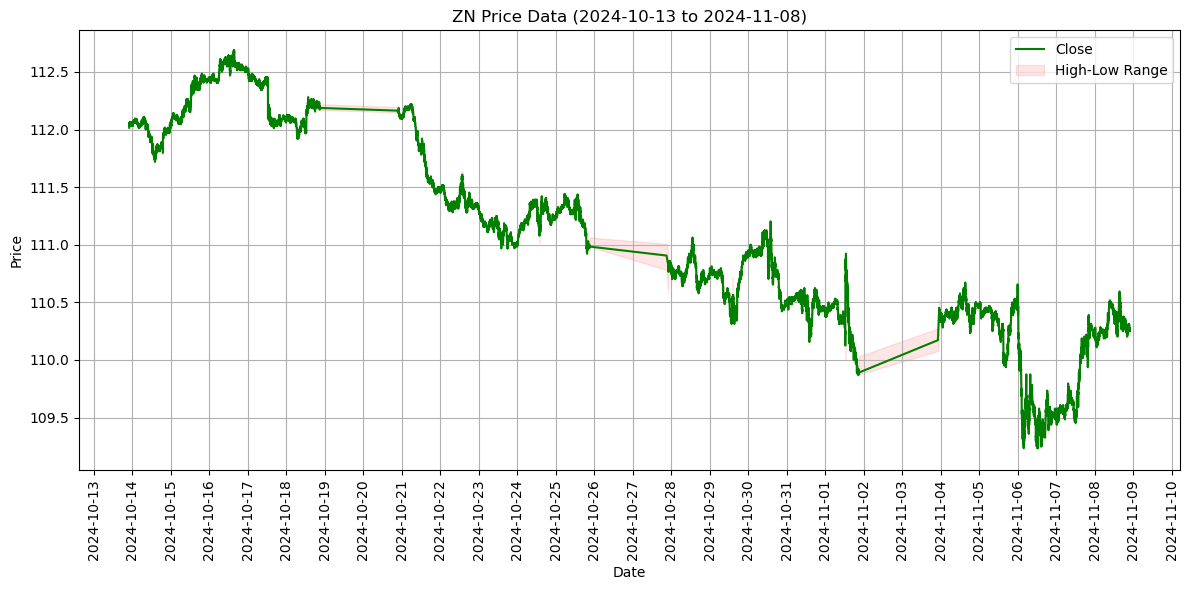


Actual date range of data:
Start: 2024-10-13 21:12:00+00:00
End: 2024-11-08 21:59:00+00:00
Total periods: 28469

Last one month - Intraday returns data Summary 2024-11-09 to 2024-10-12 for ZN (bps and ticks):
Price                       Adj Close       Close        High         Low  \
Datetime                                                                    
2024-10-13 21:12:00+00:00  102.915001  102.915001  102.915001  102.915001   
2024-10-13 22:00:00+00:00  102.952003  102.952003  102.952003  102.931999   
2024-10-13 22:01:00+00:00  102.973000  102.973000  102.973000  102.950996   
2024-10-13 22:02:00+00:00  102.964996  102.964996  102.974998  102.964996   
2024-10-13 22:03:00+00:00  102.962997  102.962997  102.964996  102.959000   
...                               ...         ...         ...         ...   
2024-11-08 21:55:00+00:00  104.947998  104.947998  104.956001  104.946999   
2024-11-08 21:56:00+00:00  104.950996  104.950996  104.950996  104.945999   
2024-11-08 21:57:00+

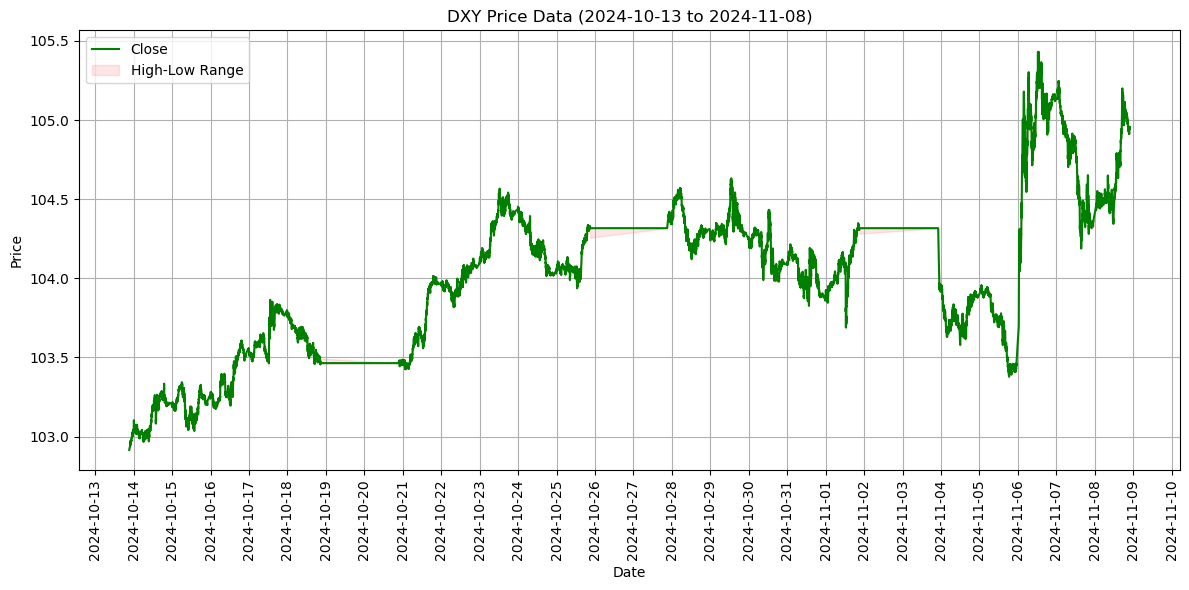


Actual date range of data:
Start: 2024-10-13 21:12:00+00:00
End: 2024-11-08 21:59:00+00:00
Total periods: 28469

Last one month - Intraday returns data Summary 2024-11-09 to 2024-10-12 for ZN (bps and ticks):
Price                      Adj Close      Close       High        Low  \
Datetime                                                                
2024-10-13 21:12:00+00:00        NaN        NaN        NaN        NaN   
2024-10-13 22:00:00+00:00  74.779999  74.779999  75.080002  74.709999   
2024-10-13 22:01:00+00:00  74.820000  74.820000  74.879997  74.730003   
2024-10-13 22:02:00+00:00  74.739998  74.739998  74.849998  74.739998   
2024-10-13 22:03:00+00:00  74.699997  74.699997  74.760002  74.639999   
...                              ...        ...        ...        ...   
2024-11-08 21:55:00+00:00  70.430000  70.430000  70.459999  70.410004   
2024-11-08 21:56:00+00:00  70.440002  70.440002  70.440002  70.410004   
2024-11-08 21:57:00+00:00  70.430000  70.430000  70.440002  

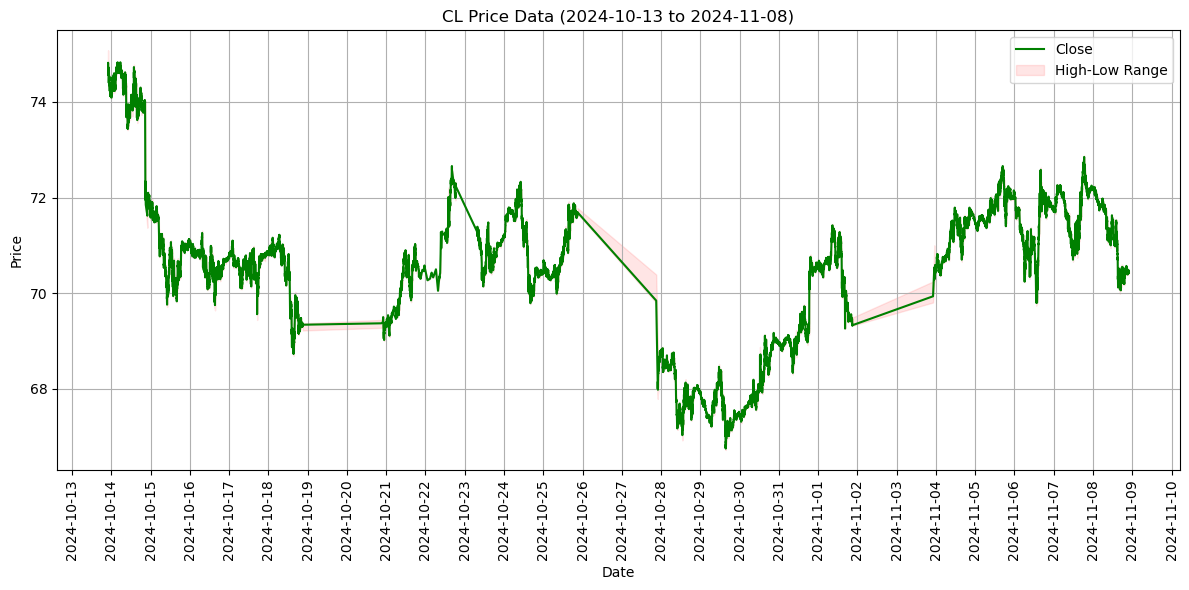


Actual date range of data:
Start: 2024-10-13 21:12:00+00:00
End: 2024-11-08 21:59:00+00:00
Total periods: 28469

Last one month - Intraday returns data Summary 2024-11-09 to 2024-10-12 for ZN (bps and ticks):
Price                        Adj Close        Close         High          Low  \
Datetime                                                                        
2024-10-13 21:12:00+00:00          NaN          NaN          NaN          NaN   
2024-10-13 22:00:00+00:00  2668.899902  2668.899902  2673.800049  2668.699951   
2024-10-13 22:01:00+00:00  2663.000000  2663.000000  2670.500000  2662.500000   
2024-10-13 22:02:00+00:00  2662.800049  2662.800049  2668.000000  2661.500000   
2024-10-13 22:03:00+00:00  2666.199951  2666.199951  2666.600098  2660.899902   
...                                ...          ...          ...          ...   
2024-11-08 21:55:00+00:00  2691.800049  2691.800049  2692.100098  2691.500000   
2024-11-08 21:56:00+00:00  2691.800049  2691.800049  2691.800

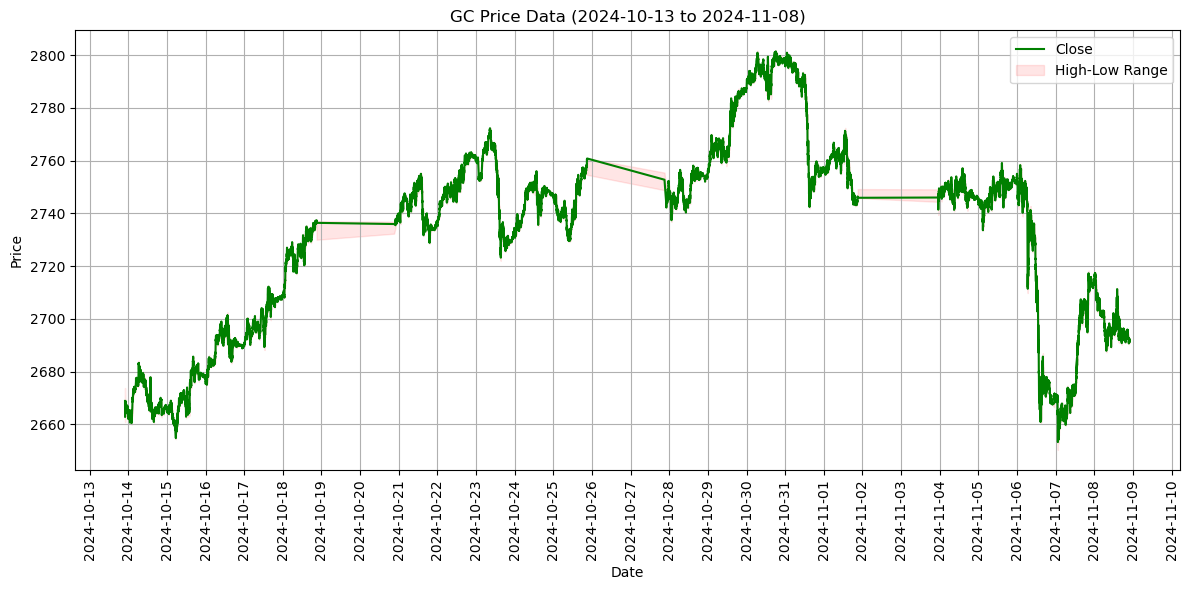


Actual date range of data:
Start: 2024-10-13 21:12:00+00:00
End: 2024-11-08 21:59:00+00:00
Total periods: 28469

Last one month - Intraday returns data Summary 2024-11-09 to 2024-10-12 for ZN (bps and ticks):
Price                      Adj Close     Close      High       Low      Open  \
Datetime                                                                       
2024-10-13 21:12:00+00:00        NaN       NaN       NaN       NaN       NaN   
2024-10-13 22:00:00+00:00   20428.00  20428.00  20440.00  20423.25  20432.50   
2024-10-13 22:01:00+00:00   20420.75  20420.75  20427.00  20418.00  20427.00   
2024-10-13 22:02:00+00:00   20420.50  20420.50  20422.75  20415.75  20420.75   
2024-10-13 22:03:00+00:00   20413.25  20413.25  20425.25  20407.50  20421.25   
...                              ...       ...       ...       ...       ...   
2024-11-08 21:55:00+00:00   21235.00  21235.00  21237.00  21229.75  21230.00   
2024-11-08 21:56:00+00:00   21234.00  21234.00  21235.50  21232.25  21

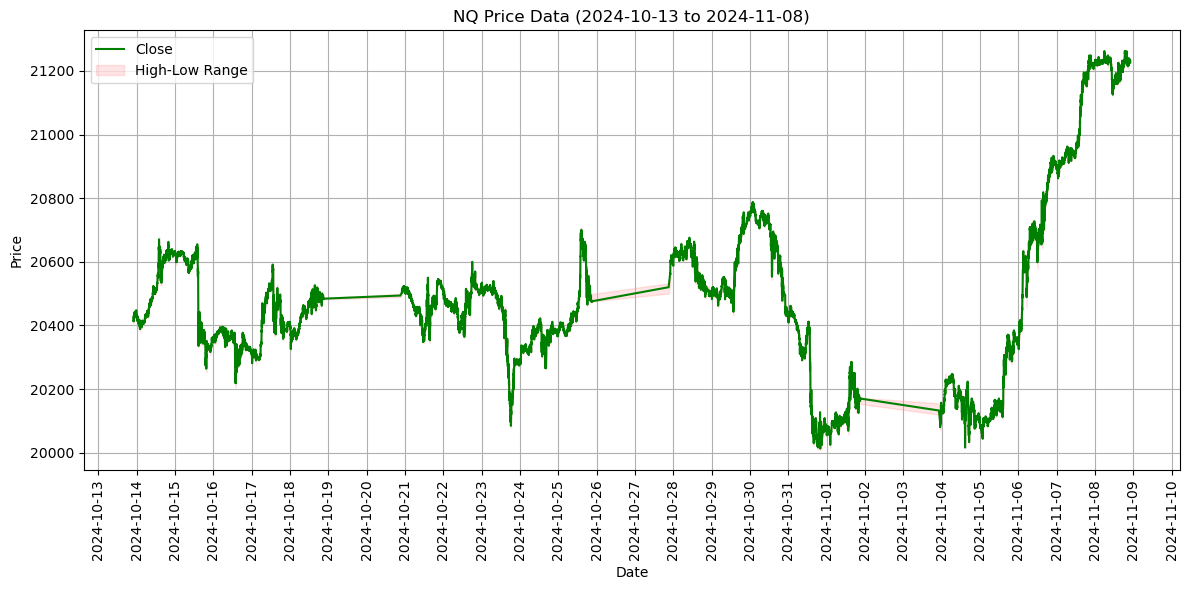


Actual date range of data:
Start: 2024-10-13 21:12:00+00:00
End: 2024-11-08 21:59:00+00:00
Total periods: 28469

Last one month - Intraday returns data Summary 2024-11-09 to 2024-10-12 for ZN (bps and ticks):
Price                      Adj Close  Close  High  Low  Open  Volume
Datetime                                                            
2024-10-13 21:12:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-10-13 22:00:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-10-13 22:01:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-10-13 22:02:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-10-13 22:03:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
...                              ...    ...   ...  ...   ...     ...
2024-11-08 21:55:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-11-08 21:56:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-11-08 21:57:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-11-08 21:58:00+00:00      

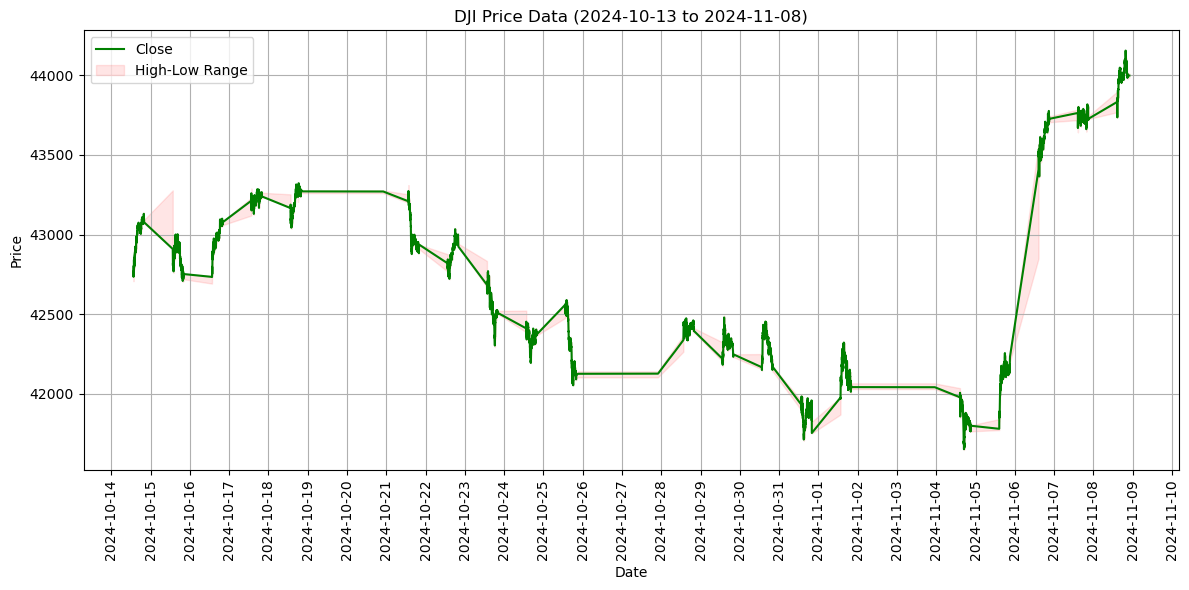


Actual date range of data:
Start: 2024-10-13 21:12:00+00:00
End: 2024-11-08 21:59:00+00:00
Total periods: 28469

Last one month - Intraday returns data Summary 2024-11-09 to 2024-10-12 for ZN (bps and ticks):
Price                      Adj Close  Close  High  Low  Open  Volume
Datetime                                                            
2024-10-13 21:12:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-10-13 22:00:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-10-13 22:01:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-10-13 22:02:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-10-13 22:03:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
...                              ...    ...   ...  ...   ...     ...
2024-11-08 21:55:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-11-08 21:56:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-11-08 21:57:00+00:00        NaN    NaN   NaN  NaN   NaN     NaN
2024-11-08 21:58:00+00:00      

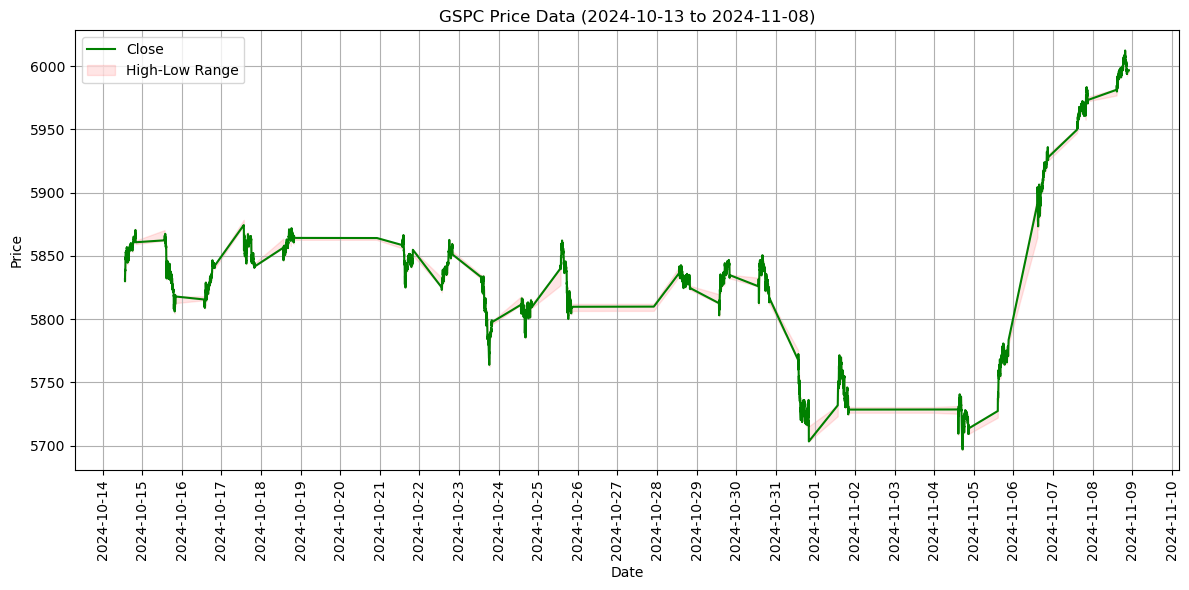


Actual date range of data:
Start: 2024-10-13 21:12:00+00:00
End: 2024-11-08 21:59:00+00:00
Total periods: 28469


In [23]:
# 1 Returns for all tickers in pts
for key_of_col in list(dict_symbols.keys()):
    sy=dict_symbols[key_of_col][0]#symbol to be displayed as filename to prevent errors later
    try:
        data = dict_symbols[key_of_col][2] #Data for that symbol.
        if data.empty:
            raise ValueError("No data available for the specified date range.")
        # Print data
        # Print some statistics
        print(f"\nLast one month - Intraday returns data Summary {start_intraday} to {end_intraday} for ZN (bps and ticks):")
      
        output_file = os.path.join(
            output_dir, "Intraday_monthly_summary_" + str(sy) + '_'+f"{name}.csv"
        )
        output_file2 = os.path.join(
            output_dir, "Intraday_monthly_data_" + str(sy) + '_'+f"{name}.csv"
        )
        data.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_csv(output_file)
        data.to_csv(output_file2)
        # Plot the data
        plt.figure(figsize=(12, 6))
    
        # Plot Adj Close as a line
        print(data)
        data["Close"] = data["Close"].interpolate()
        data["High"] = data["High"].interpolate()
        data["Low"] = data["Low"].interpolate()
        plt.plot(data.index, data["Close"], label="Close", color="green")
       


        # Set the date format for x-axis
        ax = plt.gca()  # Get current axis
        ax.xaxis.set_major_locator(mdates.DayLocator())  # Set major ticks for each day
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format ticks to show date only
       
        plt.xticks(rotation=90)
        # Shade the area between High and Low
       
        plt.fill_between(data.index, data["Low"],data["High"],alpha=0.1,color="red",label="High-Low Range")
    
        plt.title(
            f"{str(sy)} Price Data ({data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')})"
        )
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        output_file3 = os.path.join(
            output_dir, "Monthly_intraday_returns_All_Dates_" + str(sy) +'_'+ f"{name}.jpg"
        )
        plt.savefig(output_file3)
        plt.show()
    
        # Print the actual date range of the data
        print(f"\nActual date range of data:")
        print(f"Start: {data.index[0]}")
        print(f"End: {data.index[-1]}")
        print(f"Total periods: {len(data)}")
    
    except Exception as e:
        print(f"An error occurred: {e}")
        print(
            "Try adjusting the date range or check the availability of data for this symbol."
        )

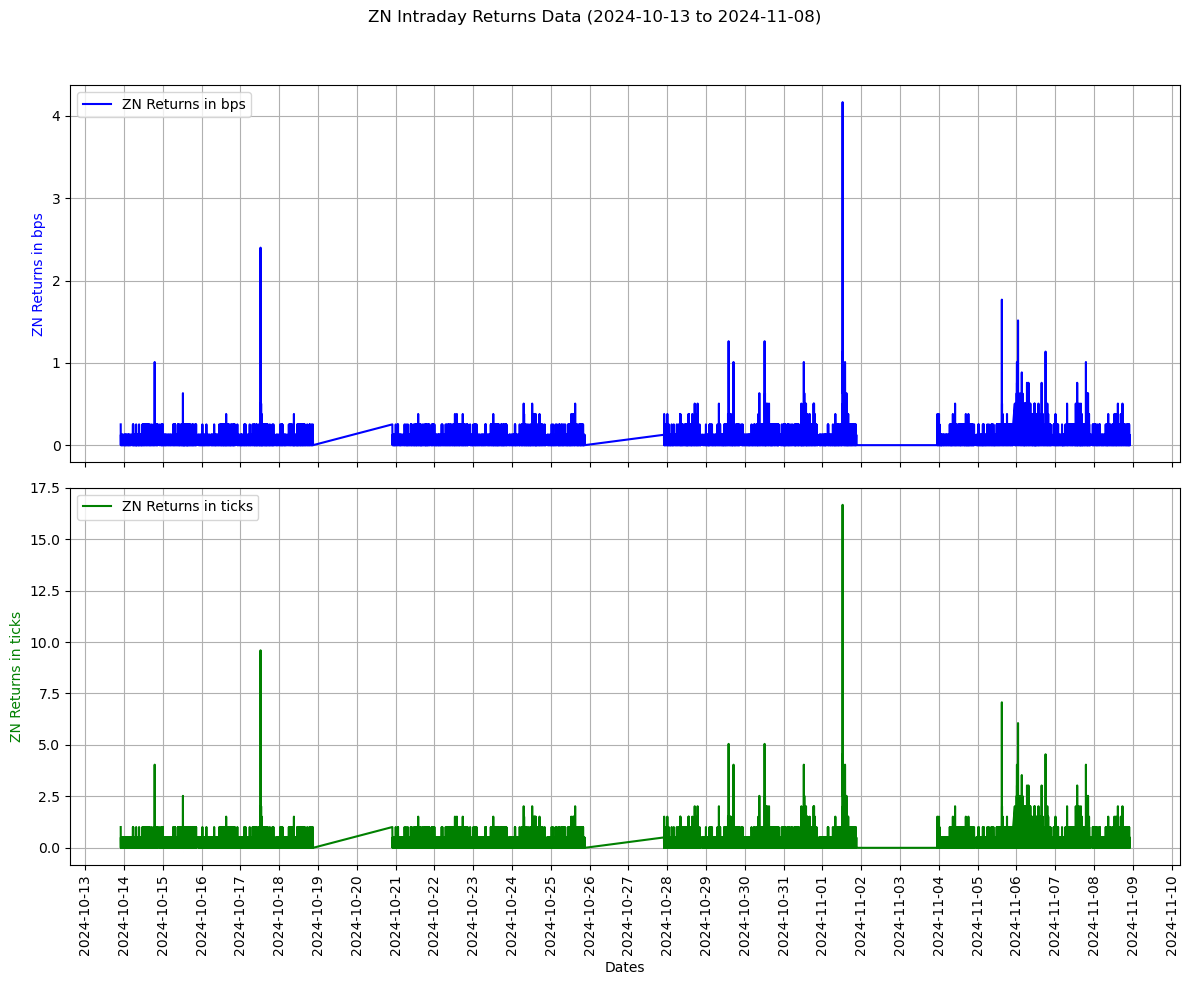


Actual date range of data:
Start: 2024-10-13 22:00:00+00:00
End: 2024-11-08 21:58:00+00:00
Total periods: 24561


In [24]:
try:
    zndata = df_zn_returns_change_bps_ticks.copy()
    if zndata.empty:
        raise ValueError("No data available for the specified date range.")
    
    zn_output_file2 = os.path.join(
        zn_output_dir, "ZN_Intraday_returns_bps_ticks_All_Dates_" + f"{zn_name}.jpg"
    )

    # Set up the figure and two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot ZN Returns in bps on the first subplot
    x = zndata.index
    y1 = zndata['bps']
    ax1.plot(x, y1, 'b-', label='ZN Returns in bps')
    ax1.set_ylabel('ZN Returns in bps', color='b')
    ax1.legend(loc='upper left')
    ax1.grid(True)
    
    # Plot ZN Returns in ticks on the second subplot
    y2 = zndata['ticks']
    ax2.plot(x, y2, 'g-', label='ZN Returns in ticks')
    ax2.set_ylabel('ZN Returns in ticks', color='g')
    ax2.set_xlabel('Dates')
    ax2.legend(loc='upper left')
    ax2.grid(True)
    
    # Set date format for x-axis (shared)
    ax2.xaxis.set_major_locator(mdates.DayLocator())  # Set major ticks for each day
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format ticks to show date only
    plt.xticks(rotation=90)
    
    # Add an overall title
    fig.suptitle(
        f"ZN Intraday Returns Data ({zndata.index[0].strftime('%Y-%m-%d')} to {zndata.index[-1].strftime('%Y-%m-%d')})"
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for the title

    # Save the plot
    plt.savefig(zn_output_file2)
    
    # Display the plot
    plt.show()

    # Print the actual date range of the data
    print(f"\nActual date range of data:")
    print(f"Start: {zndata.index[0]}")
    print(f"End: {zndata.index[-1]}")
    print(f"Total periods: {len(zndata)}")

except Exception as e:
    print(f"An error occurred: {e}")
    print(
        "Try adjusting the date range or check the availability of data for this symbol."
    )